In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("../data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
bmi_bins = [0, 18.5, 25, 30, 100]
bmi_labels = [
    "Underweight",
    "Normal",
    "Overweight",
    "Obese"
]
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=bmi_bins,
    labels=bmi_labels
)

df[["BMI", "BMI_Category"]].head()

,BMI,BMI_Category
0,33.6,Obese
1,26.6,Overweight
2,23.3,Normal
3,28.1,Overweight
4,43.1,Obese


In [6]:
age_bins = [0, 30, 50, 100]
age_labels = [
    "Young",
    "Middle_Age",
    "Senior"
]
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

df[["Age", "Age_Group"]].head()

,Age,Age_Group
0,50,Middle_Age
1,31,Middle_Age
2,32,Middle_Age
3,21,Young
4,33,Middle_Age


In [7]:
df["Glucose_Insulin_Ratio"] = np.where(
    df["Insulin"] == 0,
    0,
    df["Glucose"] / df["Insulin"]
)
df[["Glucose", "Insulin", "Glucose_Insulin_Ratio"]].head()

,Glucose,Insulin,Glucose_Insulin_Ratio
0,148,0,0.000000
1,85,0,0.000000
2,183,0,0.000000
3,89,94,0.946809
4,137,168,0.815476


In [8]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group,Glucose_Insulin_Ratio
0,6,148,72,35,0,33.6,0.627,50,1,Obese,Middle_Age,0.000000
1,1,85,66,29,0,26.6,0.351,31,0,Overweight,Middle_Age,0.000000
2,8,183,64,0,0,23.3,0.672,32,1,Normal,Middle_Age,0.000000
3,1,89,66,23,94,28.1,0.167,21,0,Overweight,Young,0.946809
4,0,137,40,35,168,43.1,2.288,33,1,Obese,Middle_Age,0.815476


In [9]:
df.to_csv(
    "../results/pima_feature_table.csv",
    index=False
)

print("Feature table saved successfully!")

Feature table saved successfully!


In [10]:
df_corr = df.copy()
df_corr["BMI_Category"] = df_corr["BMI_Category"].cat.codes
df_corr["Age_Group"] = df_corr["Age_Group"].cat.codes

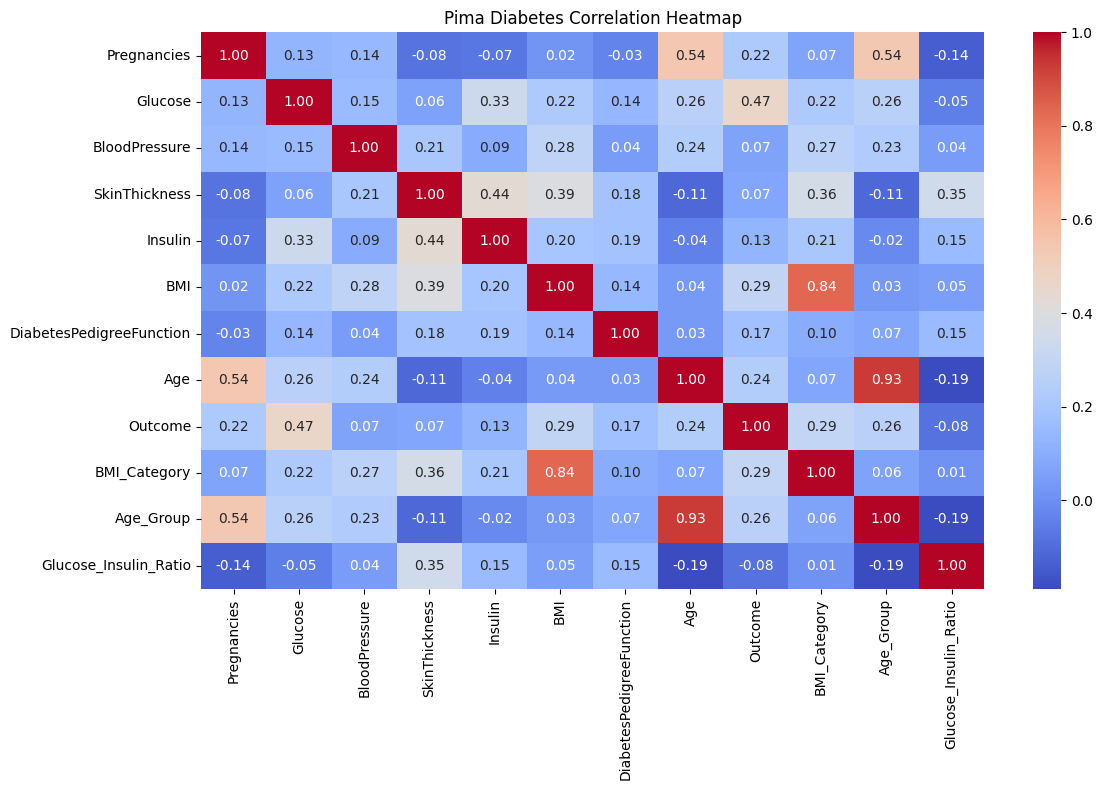

In [11]:
corr_matrix = df_corr.corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Pima Diabetes Correlation Heatmap")
plt.tight_layout()
plt.savefig(
    "../results/pima_heatmap.png",
    dpi=300
)
plt.show()